## Libraries

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model 

## GPU Configuration

In [3]:
# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

# Configure GPU memory growth (prevents TensorFlow from allocating all GPU memory at once)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n✓ GPU memory growth enabled for {len(gpus)} GPU(s)")
        
        # Optional: Enable mixed precision for better performance
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"✓ Mixed precision enabled: {policy.name}")
        
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("\n⚠ No GPU detected - training will use CPU")

TensorFlow version: 2.21.0
GPU Available: []
Built with CUDA: False

⚠ No GPU detected - training will use CPU


## Data Cleaning

In [4]:
df = pd.read_parquet('../data/telemetry/silver/cda/Telemetry_Wide_With_States')
df.sort_values(['Unit', 'Fecha'], inplace=True)
df.drop_duplicates(subset=['Unit', 'Fecha'], keep='first', inplace=True)
df.drop(columns = ['Payload', 'EngOilFltr', 'AirFltr'], inplace=True)
print(f'Total rows: {len(df)/1000000:.3f}M')

Total rows: 4.184M


In [5]:
df.isna().sum()/len(df)*100

Fecha             0.000000
Unit              0.000000
Estado            0.000000
EstadoMaquina     0.000000
EstadoCarga       0.328164
GPSLat            1.451055
GPSLon            1.451055
GPSElevation      1.260667
CnkcasePres       1.663217
DiffLubePres     27.422675
DiffTemp          2.381144
EngCoolTemp       1.404850
EngOilPres        1.759307
EngSpd            0.000000
GroundSpd         0.084664
LtExhTemp         1.344782
LtFBrkTemp        1.482009
LtRBrkTemp        1.790883
RAftrclrTemp     17.150248
RtExhTemp         1.344901
RtFBrkTemp        7.242652
RtLtExhTemp      19.819972
RtRBrkTemp        1.481077
StrgOilTemp       2.440495
TCOutTemp         1.657672
TrnLubeTemp       3.150724
dtype: float64

In [6]:
margins = {
        # General
        'GPSLat' : (-30.4, -30.1),
        'GPSLon' : (-71.3, -70.9),
        'GPSElevation' : (400, 2000),
        'GroundSpd' : (0, 80),
        'EngSpd' : (0, 2500),
        # Engine
        "EngCoolTemp" : (30, 120),
        "RAftrclrTemp" : (10, 100),
        "EngOilPres" : (150, 700),
        "EngOilFltr" : (1, 50),
        "CnkcasePres" : (-1.5, 1.5),
        "RtLtExhTemp" : (-10, 10),
        "RtExhTemp" : (150, 750),
        "LtExhTemp" : (150, 750),
        # Transmission
        "DiffLubePres" : (0, 800),
        "DiffTemp" : (0, 150),
        "TrnLubeTemp" : (-5, 120),
        "TCOutTemp" : (30, 180),
        # Brakes
        "RtRBrkTemp" : (20, 200),
        "RtFBrkTemp" : (20, 200),
        "LtRBrkTemp" : (20, 200),
        "LtFBrkTemp" : (20, 200),
        # Direction
        'StrgOilTemp' : (-10, 150),
        
}

def clean_data(df_in, margins):
    """Function that uses the margin dict to clean the values -> all the values out of range are replaced by nan"""
    df = df_in.copy()
    for col, (lower, upper) in margins.items():
        if col in df.columns:
            df[col] = df[col].where((df[col] >= lower) & (df[col] <= upper), other=pd.NA)
    return df

df_cleaned = clean_data(df, margins)
print(f'Total rows after cleaning: {len(df_cleaned)/1000000:.3f}M')

num_cols = [col for col in margins.keys() if col in df_cleaned.columns]
df_cleaned.dropna(subset=num_cols, thresh=int(len(num_cols)/2), inplace=True)
df_cleaned.fillna({'EstadoMaquina':'ND', 'EstadoCarga':'Sin Carga'}, inplace=True)
df_cleaned.reset_index(drop=True, inplace=True)

print(f'Total rows after dropping rows with significant signals missing: {len(df_cleaned)/1000000:.3f}M')

df_cleaned.head()

Total rows after cleaning: 4.184M
Total rows after dropping rows with significant signals missing: 4.129M


,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,LtFBrkTemp,LtRBrkTemp,RAftrclrTemp,RtExhTemp,RtFBrkTemp,RtLtExhTemp,RtRBrkTemp,StrgOilTemp,TCOutTemp,TrnLubeTemp
0,2025-01-01 00:02:00,T_10,ND,ND,Sin Carga,-30.254324,-71.091386,998.488372,0.151770,NaN,...,79.666667,78.000000,35.366667,250.982564,80.000000,-6.723517,78.833333,68.000000,80.739394,86.555556
1,2025-01-01 00:03:00,T_10,ND,ND,Sin Carga,-30.254331,-71.091389,996.500000,0.138828,NaN,...,79.500000,78.000000,35.275000,234.736923,79.750000,-7.042637,78.875000,68.000000,80.554545,86.416667
2,2025-01-01 00:10:00,T_10,ND,ND,Sin Carga,-30.254054,-71.091847,1000.935136,NaN,NaN,...,77.500000,76.422222,NaN,225.460740,76.833333,NaN,76.666667,63.166667,NaN,NaN
3,2025-01-01 00:11:00,T_10,ND,ND,Sin Carga,-30.254104,-71.093598,982.186666,-0.083427,NaN,...,76.800000,77.495238,35.377778,213.910555,76.416667,-5.962302,77.250000,63.375000,80.651961,83.444444
4,2025-01-01 00:12:00,T_10,ND,ND,Sin Carga,-30.252903,-71.096539,939.699995,-0.025851,51.308511,...,76.629545,80.878571,37.033333,210.314722,77.229167,-1.987033,79.808824,64.125000,80.670789,83.583333


In [7]:
df_cleaned.isna().sum()/len(df_cleaned)*100

Fecha             0.000000
Unit              0.000000
Estado            0.000000
EstadoMaquina     0.000000
EstadoCarga       0.000000
GPSLat            1.569995
GPSLon            1.569971
GPSElevation      1.263107
CnkcasePres       0.399207
DiffLubePres     26.549289
DiffTemp          1.128843
EngCoolTemp       0.262134
EngOilPres        0.774657
EngSpd            0.000145
GroundSpd         0.092851
LtExhTemp         3.452280
LtFBrkTemp        0.299720
LtRBrkTemp        0.600506
RAftrclrTemp     16.114443
RtExhTemp         4.078360
RtFBrkTemp        7.504727
RtLtExhTemp      31.539718
RtRBrkTemp        0.274388
StrgOilTemp       1.191155
TCOutTemp         1.326703
TrnLubeTemp       1.898922
dtype: float64

In [8]:
# =========================
# Config
# =========================
UNIT_COL = "Unit"
TIME_COL = "Fecha"
CAT_COLS = ["EstadoMaquina", "EstadoCarga"]  # se mantienen tal cual

FREQ = "1min"
GAP_THRESHOLD = pd.Timedelta("10min")
MIN_DURATION = pd.Timedelta("4h")
MIN_COVERAGE = 0.75
INTERP_LIMIT = 10

df_final = df_cleaned.copy()

# =========================
# 1) Calcular cycle_id en el DF original
# =========================
dt = df_final.groupby(UNIT_COL)[TIME_COL].diff()
new_cycle = dt.isna() | (dt > GAP_THRESHOLD)
df_final["cycle_id"] = new_cycle.groupby(df_final[UNIT_COL]).cumsum().astype("int64")

# =========================
# 2) Funciones auxiliares
# =========================
freq_td = pd.to_timedelta(FREQ)

def is_valid_cycle(cycle_df: pd.DataFrame) -> bool:
    """Ciclo válido si dura >= 2h y tiene suficiente densidad de muestras."""
    start = cycle_df[TIME_COL].iloc[0]
    end = cycle_df[TIME_COL].iloc[-1]
    duration = end - start

    n = len(cycle_df)
    expected_n = int(round(duration / freq_td)) + 1
    coverage = n / expected_n if expected_n > 0 else 0.0

    return (duration >= MIN_DURATION) and (coverage >= MIN_COVERAGE)

def plot_ts(df_original: pd.DataFrame, df_end: pd.DataFrame, num_cols:list = num_cols, time_col:str = TIME_COL):
    """
    Plotea una señal por figura usando seaborn/matplotlib.
    Arriba: versión original con valores faltantes.
    Abajo: versión interpolada.
    """
    for signal in num_cols:
        fig, axes = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(14, 8),
            sharex=True
        )

        # Arriba: señal original
        sns.scatterplot(
            data=df_original,
            x=time_col,
            y=signal,
            ax=axes[0],
            legend=False
        )
        axes[0].set_title(f"Original {signal}")
        axes[0].set_ylabel(signal)
        axes[0].grid(True, alpha=0.3)

        # Abajo: señal interpolada
        sns.scatterplot(
            data=df_end,
            x=time_col,
            y=signal,
            ax=axes[1],
            legend=False
        )
        axes[1].set_title(f"Interpolated {signal}")
        axes[1].set_xlabel(time_col)
        axes[1].set_ylabel(signal)
        axes[1].grid(True, alpha=0.3)

        fig.suptitle(f"Señal: {signal}", fontsize=14)
        plt.tight_layout()
        plt.show()
    
def interpolate_cycle(cycle_df: pd.DataFrame, num_cols=num_cols, viz:bool =False) -> pd.DataFrame:
    """
    Rebuild a complete 1-minute time index inside one cycle and interpolate
    only numeric signal columns.

    Assumptions:
    - cycle_df contains only one cycle
    - TIME_COL is datetime
    - cycle boundaries were already validated previously
    """
    out = cycle_df.copy()

    # Sort just in case
    out = out.sort_values(TIME_COL).reset_index(drop=True)

    # Keep original timestamps to flag which rows are newly created
    original_timestamps = set(out[TIME_COL])

    # Build full 1-minute index from start to end of the cycle
    full_time_index = pd.date_range(
        start=out[TIME_COL].min(),
        end=out[TIME_COL].max(),
        freq="1min"
    )

    # Set time as index and reindex to create missing timestamps
    out = out.set_index(TIME_COL).reindex(full_time_index)
    out.index.name = TIME_COL

    # Reconstruct metadata columns
    if UNIT_COL in cycle_df.columns:
        out[UNIT_COL] = cycle_df[UNIT_COL].iloc[0]

    if "cycle_id" in cycle_df.columns:
        out["cycle_id"] = cycle_df["cycle_id"].iloc[0]

    # Forward-fill categorical columns if you want them preserved in new rows
    for c in CAT_COLS:
        if c in cycle_df.columns:
            out[c] = out[c].ffill().bfill()

    # Only use numeric columns that actually exist
    valid_num_cols = [c for c in num_cols if c in out.columns]

    # Convert accidental object/string numeric columns
    for c in valid_num_cols:
        if out[c].dtype == "object" or pd.api.types.is_string_dtype(out[c]):
            out[c] = pd.to_numeric(out[c], errors="coerce")

    # Flag rows created by reindex
    out["created_by_reindex"] = (~out.index.isin(original_timestamps)).astype("int8")

    # Save missing positions before interpolation
    before_na = out[valid_num_cols].isna()

    # Interpolate numeric signals
    out[valid_num_cols] = out[valid_num_cols].interpolate(
        method="time",
        limit=INTERP_LIMIT,
        limit_area="inside",
    )

    # Flag rows where at least one value was imputed
    out["imputed_any"] = (
        (before_na & ~out[valid_num_cols].isna()).any(axis=1)
    ).astype("int8")
    
        # if the value its true (1% prob) we will plot the timeseries using plot_ts function, to check the interpolation results visually
    if viz:
        n_values_interpolated_per_signal_dict = (before_na & ~out[num_cols].isna()).sum().to_dict()
        max_imputed_values = max(n_values_interpolated_per_signal_dict.values()) if n_values_interpolated_per_signal_dict else 0
        if max_imputed_values/len(cycle_df) > 0.2:  # si se imputó más del 10% de los valores en alguna señal, lo ploteamos para revisar
            random_bool = np.random.choice([False, True], p=[0.996, 0.004])
            if random_bool:
                interpolated_cols = [col for col, n_imputed in n_values_interpolated_per_signal_dict.items() if n_imputed/len(cycle_df) > 0.05]
                relevant_n_values = {col: n for col, n in n_values_interpolated_per_signal_dict.items() if col in interpolated_cols}
                print(f"Cycle {cycle_df[UNIT_COL].iloc[0]}-{cycle_df['cycle_id'].iloc[0]}: Imputed values per signal: {relevant_n_values}")
                plot_ts(cycle_df, out.reset_index(), num_cols=interpolated_cols)


    return out.reset_index()

# =========================
# 3) Split -> filtrar válidos -> interpolar -> concat
# =========================
from tqdm.auto import tqdm

cycles = []
for (_, _), cycle_df in tqdm(df_final.groupby([UNIT_COL, "cycle_id"], sort=False), desc="Processing cycles"):

    if is_valid_cycle(cycle_df):
        cycles.append(interpolate_cycle(cycle_df))

cleaned_cycles_df = pd.concat(cycles, ignore_index=True) if cycles else df_final.head(0).copy()

Processing cycles:   0%|          | 0/18483 [00:00<?, ?it/s]

In [9]:
cleaned_cycles_df.isna().sum()/len(cleaned_cycles_df)*100

Fecha                  0.000000
Unit                   0.000000
Estado                 1.246282
EstadoMaquina          0.000000
EstadoCarga            0.000000
GPSLat                 1.371368
GPSLon                 1.371368
GPSElevation           1.349928
CnkcasePres            0.091563
DiffLubePres           5.929350
DiffTemp               0.574507
EngCoolTemp            0.039805
EngOilPres             0.304848
EngSpd                 0.000000
GroundSpd              0.006634
LtExhTemp              1.285317
LtFBrkTemp             0.060027
LtRBrkTemp             0.248795
RAftrclrTemp          15.888068
RtExhTemp              1.313809
RtFBrkTemp             7.485287
RtLtExhTemp           12.508617
RtRBrkTemp             0.064482
StrgOilTemp            1.147796
TCOutTemp              0.804233
TrnLubeTemp            1.647437
cycle_id               0.000000
created_by_reindex     0.000000
imputed_any            0.000000
dtype: float64

cycle_id
1156    5603
946     5556
776     5072
814     4766
474     4658
864     4616
15      4565
851     4547
30      4504
510     4329
Name: Fecha, dtype: int64

cycle_id
1314    260
1335    260
1531    255
1822    254
79      252
1713    250
1699    249
1795    248
1179    247
658     244
Name: Fecha, dtype: int64

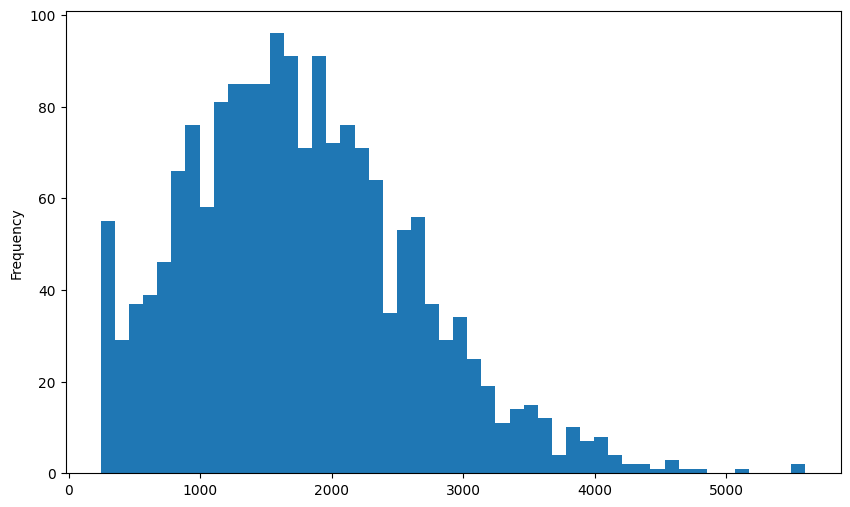

In [10]:
cycles_rows = cleaned_cycles_df.groupby('cycle_id')['Fecha'].count().sort_values(ascending=False)
cycles_rows.plot(kind='hist', bins=50, figsize=(10,6))

display(cycles_rows.iloc[:10])

display(cycles_rows.iloc[-10:])

In [11]:
percentile_dict = {col : cleaned_cycles_df[col].quantile([0.05, 0.95]) for col in num_cols if ('GPS' not in col) & ('Spd' not in col)}

out_cols = []
for col in percentile_dict.keys():
    cleaned_cycles_df.loc[:, f'{col}_out_range'] = ~cleaned_cycles_df[col].between(percentile_dict[col][0.05], percentile_dict[col][0.95])
    out_cols.append(f'{col}_out_range') 
    
cycle_summary = cleaned_cycles_df.groupby(['Unit', 'cycle_id'])[out_cols].sum()
cycle_total = cleaned_cycles_df.groupby(['Unit', 'cycle_id']).size().rename('total_rows')
cycle_summary.loc[:, 'total_out_range'] = cycle_summary[out_cols].sum(axis=1)
cycle_summary = cycle_summary.merge(cycle_total, left_index=True, right_index=True)
cycle_summary.loc[:, 'total_ratio'] = cycle_summary['total_out_range'] / cycle_summary['total_rows']
# if ratio < 2.0 => Normal, else Anomalous
cycle_summary.loc[:, 'Label'] = np.where(cycle_summary['total_ratio'] < 1.2, 'Normal', 'Anomalous')

In [12]:
cleaned_cycles_df = cleaned_cycles_df.merge(cycle_summary['Label'], left_on=['Unit', 'cycle_id'], right_index=True)

del cycles, cycle_summary, cycle_total
del percentile_dict, out_cols
del df, df_cleaned, df_final

cleaned_cycles_df

,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,DiffLubePres_out_range,DiffTemp_out_range,TrnLubeTemp_out_range,TCOutTemp_out_range,RtRBrkTemp_out_range,RtFBrkTemp_out_range,LtRBrkTemp_out_range,LtFBrkTemp_out_range,StrgOilTemp_out_range,Label
0,2025-01-01 10:05:00,T_10,ND,ND,Sin Carga,-30.254391,-71.088554,984.782691,-0.336347,NaN,...,True,False,True,True,True,True,True,True,True,Normal
1,2025-01-01 10:06:00,T_10,ND,ND,Sin Carga,-30.254361,-71.088596,989.330357,-0.322655,NaN,...,True,False,False,False,True,True,False,True,False,Normal
2,2025-01-01 10:07:00,T_10,ND,ND,Sin Carga,-30.254359,-71.088587,995.527269,-0.307973,NaN,...,True,False,False,False,True,False,False,False,False,Normal
3,2025-01-01 10:08:00,T_10,ND,ND,Sin Carga,-30.254393,-71.088536,984.842000,-0.292973,NaN,...,True,True,False,False,True,False,False,False,False,Normal
4,2025-01-01 10:09:00,T_10,ND,ND,Sin Carga,-30.254457,-71.088697,998.712070,-0.242314,NaN,...,True,True,False,False,True,False,False,False,False,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3120236,2026-01-30 23:56:00,T_9,Operacional,Operacional Alto,Sin Carga,-30.254518,-71.096484,1023.049999,0.107313,131.404679,...,False,False,False,False,False,False,False,False,False,Normal
3120237,2026-01-30 23:57:00,T_9,Operacional,Operacional Alto,Sin Carga,-30.250783,-71.099808,1050.487712,0.091365,143.147552,...,False,False,False,False,False,False,False,False,False,Normal
3120238,2026-01-30 23:58:00,T_9,Ralenti,Ralenti Alto,Sin Carga,-30.246659,-71.101252,1052.864915,0.069494,139.727043,...,False,False,False,False,False,False,False,False,False,Normal
3120239,2026-01-30 23:59:00,T_9,Ralenti,Ralenti Alto,Sin Carga,-30.247095,-71.100186,1004.574576,0.073976,141.599384,...,False,False,False,False,False,False,False,False,False,Normal


## Model

In [13]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import json
import joblib

DROPOUT_RATE = 0.2
WINDOW_SIZE = 1 * 60 # 1 hour of data at 1-minute frequency = 60 time steps
WEEKS_TO_TEST = 6
df_train = cleaned_cycles_df[cleaned_cycles_df[TIME_COL] < cleaned_cycles_df[TIME_COL].max() - pd.Timedelta(weeks=WEEKS_TO_TEST)]
df_test = cleaned_cycles_df[cleaned_cycles_df[TIME_COL] >= cleaned_cycles_df[TIME_COL].max() - pd.Timedelta(weeks=WEEKS_TO_TEST)]

component_mapping = json.load(open('../data/telemetry/component_signals_mapping.json', 'r'))
def build_lstm_autoencoder(n_signals: int, n_cat_signals: int, sequence_length: int):
    """
    Build LSTM autoencoder for multivariate telemetry.
    
    Args:
        n_signals: Number of input signals (features)
        n_cat_signals: Number of categorical signals to be included in the model (after one-hot encoding)
        sequence_length: Time steps in sequence (e.g., 168 hours for 1 week)
    """
    # Encoder
    encoder_inputs = layers.Input(shape=(sequence_length, n_signals+n_cat_signals))
    x = layers.LSTM(16, return_sequences=True)(encoder_inputs)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.LSTM(8, return_sequences=False)(x)
    encoder = Model(encoder_inputs, x, name='encoder')
    
    # Decoder
    decoder_input = layers.Input(shape=(8,))
    x = layers.RepeatVector(sequence_length)(decoder_input)
    x = layers.LSTM(8, return_sequences=True)(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.LSTM(16, return_sequences=True)(x)
    decoder_output = layers.TimeDistributed(layers.Dense(n_signals))(x)
    decoder = Model(decoder_input, decoder_output, name='decoder')
    
    # Full autoencoder
    autoencoder_input = layers.Input(shape=(sequence_length, n_signals+n_cat_signals))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    autoencoder = Model(autoencoder_input, decoded, name='autoencoder')
    
    # Compile model
    autoencoder.compile(optimizer='adam', loss='mse')
    
    return autoencoder, encoder, decoder

def get_scalers(df: pd.DataFrame, component:str, is_training:bool = True) -> dict:
    """
    Get scalers for signals and categorical variables.
    If training, fit scalers on Normal data only. If inference, load them from models/{component}/scalers/{unit}_{type}_scaler.pkl (if exist)
    """
    if is_training:
        signal_scaler = RobustScaler()
        cat_scaler = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)  # drop='first' para evitar multicolinealidad
        scalers = {
            'categorical': cat_scaler,
            'signal' : {
                unit : signal_scaler for unit in df['Unit'].unique()
            }
        }
        return scalers
        
    else:
        signal_scaler_path = 'models/{component}/scalers/{unit}_signal_scaler.pkl'
        cat_scaler_path = f'models/{component}/scalers/cat_scaler.pkl'
        scalers = {
            'categorical': joblib.load(cat_scaler_path),
            'signal' : {
                unit : joblib.load(signal_scaler_path.format(component=component, unit=unit)) for unit in df['Unit'].unique()
            }
        }
        return scalers

def create_sequences(df: pd.DataFrame, 
                     component: str,
                     signal_cols: list, 
                     cat_cols: list = CAT_COLS,
                     window_size: int =WINDOW_SIZE, 
                     is_training: bool = True):
    """
    Create sequences using sliding window approach.
    If training, only uses Normal data to create sequences. If inference, uses all data.
    If training data, we impute missing values with median (or mean) before creating sequences, to avoid losing too much data. If inference, we impute missing values at -10 after scaling them.
    
    
    Args:
        df: DataFrame with telemetry data for a single unit and cycle.
        signal_cols: List of signal columns to include in sequences.
        window_size: Number of time steps in each sequence.
        is_training: If True, only creates sequences from Normal data (for training).
                     If False, creates sequences from all data (for inference).
    """
    signal_sequences = []
    categorical_sequences = []
    
    # Filter data if training, to use only Normal data for training the autoencoder. For inference, we will use all the data to create sequences and then we will use the autoencoder to detect anomalies in those sequences.
    if is_training:
        if 'Label' in df.columns:
            df = df[df['Label'] == 'Normal'].copy()  # Use only Normal data for training
        else:
            print("Warning: 'Label' column not found in DataFrame. Using all data for training.")
    
    scalers = get_scalers(df, component, is_training=is_training)
    
    if is_training:
        ohe = scalers['categorical']
        ohe.fit(df[cat_cols])
        cat_cols_encoded = list(ohe.get_feature_names_out())
        # store ohe 
        import os
        os.makedirs(f'models/{component}/scalers', exist_ok=True)
        joblib.dump(ohe, f'models/{component}/scalers/cat_scaler.pkl')
        
        for unit in df['Unit'].unique():
            sc = scalers['signal'][unit]
            unit_data = df[df['Unit'] == unit].copy()
            sc.fit(unit_data[signal_cols])
            joblib.dump(sc, f'models/{component}/scalers/{unit}_signal_scaler.pkl')
            
            unit_data[signal_cols] = unit_data[signal_cols].fillna(unit_data[signal_cols].median())  # Imputar valores faltantes con la mediana antes de escalar (solo para entrenamiento)
            unit_data[signal_cols] = sc.transform(unit_data[signal_cols])  # Escalar señales antes de crear secuencias
            unit_data.loc[:, cat_cols_encoded] = ohe.transform(unit_data[cat_cols])  # Codificar variables categóricas
              
            for cycle in unit_data['cycle_id'].unique():
                cycle_data = unit_data[unit_data['cycle_id'] == cycle][signal_cols + cat_cols_encoded].values
                
                if cycle_data.shape[0] < window_size*2:  # Solo crear secuencias si el ciclo tiene suficientes datos para al menos una ventana
                    continue
                
                # Create sliding windows - per cycle -- Note : Each unit has very cycle, so we will create the windows for each unit separately to avoid mixing different units in the same sequence
                for i in range(len(cycle_data) - window_size):
                    signal_sequences.append(cycle_data[i:i+window_size, :len(signal_cols)])  # Solo señales en la entrada del autoencoder
                    categorical_sequences.append(cycle_data[i:i+window_size, len(signal_cols):])  # Solo variables categóricas en la entrada del autoencoder
    else:
        # for inference we assume that we have exactly one cycle per unit, so we will create one sequence per unit with the first window_size time steps, and we will impute missing values with -10 after scaling them, to avoid losing data and to be able to detect anomalies in those sequences.
        ohe = scalers['categorical']
        cat_cols_encoded = list(ohe.get_feature_names_out())
        for unit in df['Unit'].unique():
            sc = scalers['signal'][unit]
            unit_data = df[df['Unit'] == unit].copy()
            unit_data[signal_cols] = sc.transform(unit_data[signal_cols])  # Escalar señales antes de crear secuencias
            unit_data[signal_cols] = unit_data[signal_cols].fillna(-10)  # Imputar valores faltantes con -10 después de escalar (solo para inferencia)
            unit_data.loc[:, cat_cols_encoded] = ohe.transform(unit_data[cat_cols])  # Codificar variables categóricas
            cycle_data = unit_data[signal_cols + cat_cols_encoded].values
            if cycle_data.shape[0] < window_size:  # Si el ciclo no tiene suficientes datos para una ventana completa, lo saltamos
                continue
            signal_sequences.append(cycle_data[:window_size, :len(signal_cols)])  # Solo señales en la entrada del autoencoder
            categorical_sequences.append(cycle_data[:window_size, len(signal_cols):])  # Solo variables categóricas en la entrada del autoencoder
            
    return np.array(signal_sequences), np.array(categorical_sequences)
            
def train_lstm_autoencoder(
    training_df: pd.DataFrame,
    component_mapping: dict,
    client: str,
    component: str
):
    """
    Train LSTM autoencoder on historical normal data for a component.
    """
    signal_cols = component_mapping['components'][component]['signals']
    signal_cols = [col for col in signal_cols if col in training_df.columns]
            
    signal_sequences, categorical_sequences = create_sequences(training_df, component, signal_cols, is_training=True)
    # X matrix is signals+categoricals while y matrix is only signals, since we want the autoencoder to reconstruct only the signal values, while the categorical variables are used as additional features in the input to help the model learn better representations of the data, but we don't want the model to reconstruct them, since they are not continuous variables and they don't have a meaningful reconstruction error.
    X_train = np.concatenate([signal_sequences, categorical_sequences], axis=-1)
    y_train = signal_sequences  # Solo las señales como target para el autoencoder
    print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
    
    # Build and train model
    model, encoder, decoder = build_lstm_autoencoder(
        n_signals=len(signal_cols),
        n_cat_signals=categorical_sequences.shape[-1] if categorical_sequences.size > 0 else 0,
        sequence_length=WINDOW_SIZE
    )
    
    model.fit(
        X_train, y_train,
        epochs=2,
        batch_size=32,
        validation_split=0.2,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        ]
    )
    
    # Save model
    import os
    os.makedirs(f'models/autoencoders/{client}', exist_ok=True)
    model_path = f"models/autoencoders/{client}/{component}_lstm_ae.keras"
    model.save(model_path)
    
    return model

# model = train_lstm_autoencoder(df_train, component_mapping, 'cda', 'Tren de fuerza')

In [ ]:
# Model Prediction
# for inference we assume that we have exactly one cycle per unit, so we will focus on securing the window is complete and has exactly WINDOW_SIZE records.
def prepare_inference_data(df: pd.DataFrame, start_time: pd.Timestamp = None, end_time: pd.Timestamp = None) -> pd.DataFrame:
    '''
    Prepare data to make an inference.
    Per each unit, we force a timeindex from start_time to end_time with frequency of 1 minute, and we keep only the first WINDOW_SIZE records, to ensure that we have a complete window for inference.
    Nans are kept as they are, since the create_sequences function will impute them with -10 after scaling them, to avoid losing data and to be able to detect anomalies in those sequences.
    '''
    out = []
    unit_list = list(df['Unit'].unique())
    for unit in unit_list:
        unit_data = df[df['Unit'] == unit].copy()
        if start_time is not None and end_time is not None:
            full_time_index = pd.date_range(start=start_time, end=end_time, freq='1min')
            unit_data = unit_data.set_index(TIME_COL).reindex(full_time_index).reset_index().rename(columns={'index': TIME_COL})
            unit_data[UNIT_COL] = unit  # Fill Unit column for new rows
        out.append(unit_data.head(WINDOW_SIZE))  # Keep only the first WINDOW_SIZE records to ensure we have a complete window for inference
        
    return pd.concat(out, ignore_index=True), unit_list
    
def inference_window(
    model: Model,
    df_in: pd.DataFrame,
    component_mapping: dict,
    component: str,
    cat_cols: list = CAT_COLS,
    window_size: int = WINDOW_SIZE,
):
    """
    Run inference on a single window of data for a component.
    
    Args:
        model: Trained LSTM autoencoder model.
        df: DataFrame with telemetry data for a single unit and cycle.
        component_mapping: Dictionary mapping components to their signals.
        component: Component name to select relevant signals.
    """
    signal_cols = component_mapping['components'][component]['signals']
    
    signal_sequences, categorical_sequences = create_sequences(df_in, component, signal_cols, cat_cols, window_size, is_training=False)
    X = np.concatenate([signal_sequences, categorical_sequences], axis=-1)
    predictions = model.predict(X)
    return predictions

# We must de scalate the predictions to be able to calculate the reconstruction error in the original scale of the signals, and then we can set a threshold to detect anomalies based on the reconstruction error.
# To do that, we will have 2 methods : 
# i) predict window : this method will take a window of data, prepare the data for inference, run the inference and return the predictions in the original scale of the signals, ready to be compared with the original values to calculate the reconstruction error and detect anomalies.
# ii) compute_health_index : this method will take the original values and the predicted values for a window, calculate the reconstruction error, and return a health index based on the reconstruction error, where a higher reconstruction error indicates a lower health index (more anomalous) and a lower reconstruction error indicates a higher health index (more normal).
# To compute longer windows (weeks or days) we need to call this function several times.
def predict_window(df:pd.DataFrame, start_time: pd.Timestamp, end_time: pd.Timestamp, component_mapping: dict, component: str):
    '''
    This method will take a window of data, prepare the data for inference, run the inference and return the predictions in the original scale of the signals, ready to be compared with the original values to calculate the reconstruction error and detect anomalies.
    '''
    scalers = get_scalers(df, component, is_training=False)['signal']
    signal_cols = scalers[df['Unit'].unique()[0]].feature_names_in_  # Obtener los nombres de las señales a partir del scaler (asumiendo que todos los scalers tienen las mismas señales)
    model = tf.keras.models.load_model(f'models/autoencoders/cda/{component}_lstm_ae.keras')
    prepared_df, unit_list = prepare_inference_data(df, start_time, end_time)
    predictions_scaled = inference_window(model, prepared_df, component_mapping, component)
    
    predictions_unscaled = []
    for i, unit in enumerate(unit_list):
        sc = scalers[unit]
        pred_unscaled = sc.inverse_transform(predictions_scaled[i])
        pred_unscaled = pd.DataFrame(pred_unscaled, columns=signal_cols)
        pred_unscaled['Unit'] = unit
        pred_unscaled['Fecha'] = prepared_df[prepared_df['Unit'] == unit][TIME_COL].values[:len(pred_unscaled)]
        predictions_unscaled.append(pred_unscaled)
        
    return pd.concat(predictions_unscaled, ignore_index=True)

def compute_health_index_from_reconstruction(
    df_original: pd.DataFrame,
    df_predicted: pd.DataFrame,
    signal_cols: list,
    error_stats: dict,
    alpha: float = 1.0,
    agg_method: str = "mean",
    eps: float = 1e-8,
):
    """
    Compute a health index from reconstruction errors.

    Steps:
    1. Merge original and predicted data
    2. Compute per-signal absolute reconstruction error
    3. Normalize each signal error using P50/P95 from error_stats
    4. Aggregate normalized errors across signals at each timestamp
    5. Convert aggregated error into pointwise HI
    6. Aggregate HI over time at Unit level

    Parameters
    ----------
    df_original : pd.DataFrame
        Original dataframe with real signals.
    df_predicted : pd.DataFrame
        Predicted/reconstructed dataframe.
    signal_cols : list
        Signal names, e.g. ["sig1", "sig2", "sig3", "sig4"]
    error_stats : dict
        Dict like:
        {
            "sig1": {"p50": ..., "p95": ...},
            ...
        }
    alpha : float
        Controls HI decay in exp(-alpha * error).
    agg_method : str
        Temporal aggregation at unit level. Options:
        "mean", "median", "min", "p10"
    eps : float
        Numerical stability.

    Returns
    -------
    merged : pd.DataFrame
        Timestamp-level dataframe with reconstruction errors and pointwise HI.
    unit_hi : pd.DataFrame
        Unit-level aggregated HI.
    """

    # -----------------------------
    # Step 1: Merge
    # -----------------------------
    merged = df_original.merge(
        df_predicted,
        on=[UNIT_COL, TIME_COL],
        suffixes=("_orig", "_pred"),
        how="inner"
    ).copy()

    # Ensure sorted output
    merged = merged.sort_values([UNIT_COL, TIME_COL]).reset_index(drop=True)

    norm_error_cols = []
    raw_error_cols = []

    # -----------------------------
    # Step 2 + 3: reconstruction error + normalization
    # -----------------------------
    for col in signal_cols:
        orig_col = f"{col}_orig"
        pred_col = f"{col}_pred"
        err_col = f"{col}_recon_error"
        norm_col = f"{col}_norm_error"

        if orig_col not in merged.columns or pred_col not in merged.columns:
            raise KeyError(f"Missing columns for signal '{col}': {orig_col} or {pred_col}")

        if col not in error_stats:
            raise KeyError(f"Signal '{col}' not found in error_stats")

        p50 = error_stats[col]["p50"]
        p95 = error_stats[col]["p95"]

        if pd.isna(p50) or pd.isna(p95):
            raise ValueError(f"NaN p50/p95 for signal '{col}'")

        if p95 <= p50:
            raise ValueError(f"Invalid percentiles for signal '{col}': p95 must be > p50")

        # Step 2: absolute reconstruction error
        merged[err_col] = (merged[orig_col] - merged[pred_col]).abs()

        # Step 3: normalize error relative to healthy distribution
        merged[norm_col] = ((merged[err_col] - p50) / (p95 - p50 + eps)).clip(lower=0)

        raw_error_cols.append(err_col)
        norm_error_cols.append(norm_col)

    # -----------------------------
    # Step 4: aggregate across signals at each timestamp
    # -----------------------------
    merged["reconstruction_error_raw_mean"] = merged[raw_error_cols].mean(axis=1)
    merged["reconstruction_error_norm_mean"] = merged[norm_error_cols].mean(axis=1)

    # Optional: stronger penalty to large deviations
    merged["reconstruction_error_norm_rms"] = np.sqrt(
        (merged[norm_error_cols] ** 2).mean(axis=1)
    )

    # Choose one as main anomaly score
    merged["reconstruction_error_score"] = merged["reconstruction_error_norm_mean"]

    # Convert anomaly score to Health Index
    merged["health_index_point"] = np.exp(-alpha * merged["reconstruction_error_score"])

    # -----------------------------
    # Step 5: aggregate at Unit level
    # -----------------------------
    if agg_method == "mean":
        unit_hi = (
            merged.groupby(UNIT_COL, as_index=False)
            .agg(
                health_index=("health_index_point", "mean"),
                reconstruction_error=("reconstruction_error_score", "mean"),
                n_records=(TIME_COL, "count"),
                start_time=(TIME_COL, "min"),
                end_time=(TIME_COL, "max"),
            )
        )

    elif agg_method == "median":
        unit_hi = (
            merged.groupby(UNIT_COL, as_index=False)
            .agg(
                health_index=("health_index_point", "median"),
                reconstruction_error=("reconstruction_error_score", "median"),
                n_records=(TIME_COL, "count"),
                start_time=(TIME_COL, "min"),
                end_time=(TIME_COL, "max"),
            )
        )

    else:
        raise ValueError("agg_method must be one of: 'mean', 'median'")

    return merged, unit_hi


In [64]:
# 1 hour window
component = 'Tren de fuerza'
example_window = df_test[(df_test.Fecha <= df_test.Fecha + pd.Timedelta(hours=1)) & (~df_test.Unit.isin(['T_18','T_24']))].copy()  # Tomamos una ventana de ejemplo para un ciclo específico
example_window.head(3)

,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,DiffLubePres_out_range,DiffTemp_out_range,TrnLubeTemp_out_range,TCOutTemp_out_range,RtRBrkTemp_out_range,RtFBrkTemp_out_range,LtRBrkTemp_out_range,LtFBrkTemp_out_range,StrgOilTemp_out_range,Label
280850,2025-12-20 00:00:00,T_10,ND,ND,Cargado,-30.247959,-71.095482,884.748483,0.122563,57.411088,...,False,False,False,False,False,False,False,False,False,Anomalous
280851,2025-12-20 00:01:00,T_10,ND,ND,Cargado,-30.248362,-71.096139,894.005660,0.125305,53.535554,...,False,False,False,False,False,False,False,False,False,Anomalous
280852,2025-12-20 00:02:00,T_10,ND,ND,Sobrecarga,-30.247963,-71.097213,903.824999,0.126699,49.660021,...,False,False,False,False,False,False,False,False,False,Anomalous


In [65]:
df_out = predict_window(example_window, example_window[TIME_COL].min(), example_window[TIME_COL].max(), component_mapping, component)
df_out.head()

c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step


,DiffLubePres,DiffTemp,TrnLubeTemp,TCOutTemp,Unit,Fecha
0,49.103745,78.714424,85.506729,82.855515,T_10,2025-12-20 00:00:00
1,43.092281,79.869453,84.806328,81.993645,T_10,2025-12-20 00:01:00
2,38.492489,80.599869,84.664520,81.443703,T_10,2025-12-20 00:02:00
3,36.143059,80.930954,84.703400,81.103119,T_10,2025-12-20 00:03:00
4,35.290676,81.140221,84.875549,80.994843,T_10,2025-12-20 00:04:00


In [75]:
final_df = compute_health_index(example_window, df_out, component_mapping['components'][component]['signals'])
final_df.head()

,Unit,health_index,DiffLubePres_recon_error,DiffTemp_recon_error,TrnLubeTemp_recon_error,TCOutTemp_recon_error
0,T_10,0.524477,183.993899,0.437559,0.803540,4.974272
1,T_12,0.225171,299.367565,0.957947,2.098254,7.507870
2,T_14,-0.393599,550.721654,1.255503,0.499837,4.962742
3,T_15,-0.479688,578.471002,5.060363,1.214244,7.129631
4,T_16,-0.046266,412.637514,0.669345,0.247703,4.951732


In [ ]:
df_original = example_window.copy()
df_predicted = df_out.copy()

merged = df_original.merge(df_predicted, on=['Unit', 'Fecha'], suffixes=('_orig', '_pred'))
for col in signal_cols:
    merged[f'{col}_recon_error'] = (merged[f'{col}_orig'] - merged[f'{col}_pred']) ** 2  # MSE reconstruction error per signal

# recon_error_cols = [f'{col}_recon_error' for col in signal_cols]
# merged = merged.groupby('Unit')[recon_error_cols].mean().reset_index()  # Mean reconstruction error per signal per unit
# merged['total_reconstruction_error'] = merged[recon_error_cols].sum(axis=1)  # Total reconstruction error per unit
# n_features = len(signal_cols)
# merged['health_index'] = 1 - (merged['total_reconstruction_error'] / (n_features * 100))  # Health index normalized between 0 and 1
merged

,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres_orig,...,StrgOilTemp_out_range,Label,DiffLubePres_pred,DiffTemp_pred,TrnLubeTemp_pred,TCOutTemp_pred,DiffLubePres_recon_error,DiffTemp_recon_error,TrnLubeTemp_recon_error,TCOutTemp_recon_error
0,2025-12-20 00:00:00,T_10,ND,ND,Cargado,-30.247959,-71.095482,884.748483,0.122563,57.411088,...,False,Anomalous,49.103745,78.714424,85.506729,82.855515,69.011956,1.680649,2.644833,2.112880
1,2025-12-20 00:01:00,T_10,ND,ND,Cargado,-30.248362,-71.096139,894.005660,0.125305,53.535554,...,False,Anomalous,43.092281,79.869453,84.806328,81.993645,109.061952,0.030345,0.822036,0.534962
2,2025-12-20 00:02:00,T_10,ND,ND,Sobrecarga,-30.247963,-71.097213,903.824999,0.126699,49.660021,...,False,Anomalous,38.492489,80.599869,84.664520,81.443703,124.713769,0.097450,0.259509,0.214109
3,2025-12-20 00:03:00,T_10,ND,ND,Sobrecarga,-30.249031,-71.097385,919.192855,0.158954,45.784487,...,False,Anomalous,36.143059,80.930954,84.703400,81.103119,92.957142,0.062301,0.040683,0.030040
4,2025-12-20 00:04:00,T_10,ND,ND,Sobrecarga,-30.247452,-71.098804,931.160374,0.168392,50.323942,...,False,Anomalous,35.290676,81.140221,84.875549,80.994843,225.999092,1.082297,0.833578,0.891588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,2025-12-20 00:55:00,T_9,Operacional,Operacional Bajo,Cargado,-30.254003,-71.089699,995.730616,0.207453,96.971320,...,False,Anomalous,78.216721,80.111427,91.263176,90.474739,351.735012,1.871385,0.161656,20.099880
416,2025-12-20 00:56:00,T_9,Operacional,Operacional Bajo,Cargado,-30.254180,-71.089719,1006.021054,0.217205,95.247475,...,False,Anomalous,78.175858,79.445152,90.680733,90.370331,291.440114,1.804281,0.111229,25.637936
417,2025-12-20 00:57:00,T_9,Operacional,Operacional Bajo,Cargado,-30.254190,-71.089777,1012.031707,0.221302,97.690624,...,False,Anomalous,82.025505,78.737572,90.001434,89.754654,245.395962,0.292373,0.077959,14.853845
418,2025-12-20 00:58:00,T_9,Operacional,Operacional Bajo,Cargado,-30.254197,-71.089765,1008.850001,0.216443,100.133774,...,False,Anomalous,89.973625,78.139618,89.346748,88.703934,103.228623,0.386776,0.015507,6.865309


In [73]:
merged.groupby('Unit')[recon_error_cols].mean()

,DiffLubePres_recon_error,DiffTemp_recon_error,TrnLubeTemp_recon_error,TCOutTemp_recon_error
Unit,,,,
T_10,183.993899,0.437559,0.803540,4.974272
T_12,299.367565,0.957947,2.098254,7.507870
T_14,550.721654,1.255503,0.499837,4.962742
T_15,578.471002,5.060363,1.214244,7.129631
T_16,412.637514,0.669345,0.247703,4.951732
T_17,447.814451,0.447032,0.476623,5.805763
T_9,257.977447,1.384679,0.435601,3.357402
